In [1]:
# Solar Flare Data Pipeline: GOES-16 + GOES-19 + SWPC Historical Database
#
# This notebook:
#   1. Downloads GOES-16 & GOES-19 XRS flux-summary netCDF files from NOAA
#   2. Extracts individual flare events (start/peak/end) with solar position data
#   3. Loads and corrects the SWPC historical flare database (1975–2017)
#   4. Merges all three datasets into a unified XRS-B channel flare catalog
#
# Satellite coverage:
#   - SWPC (GOES-1 through GOES-15): 1975 – 2017
#   - GOES-16:                            2017 – 2024-09
#   - GOES-19:                            2024-09 – present
#
# Key detail: SWPC fluxes are divided by 0.7 to correct for the
# GOES XRS-B channel spectral response difference between older and
# newer GOES generations.

from datetime import datetime, timedelta

import netCDF4
import numpy as np
import pandas as pd
import pytz

from pysolar import solar
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
%matplotlib inline

In [2]:
# ---------------------------------------------------------------------------
# 1. Download GOES-16 & GOES-19 XRS flux-summary data from NOAA
# ---------------------------------------------------------------------------
# GOES-16: launched Nov 2016, data from Feb 2017 – April 2025
# GOES-19: launched Jun 2024, data from Sep 2024 – present (operational GOES-East)

import requests

def download_file(url: str):
    local_filename = url.split('/')[-1]
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open('data/' + local_filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    return local_filename


def netcdf4_scraper(url: str, suffix: str = ".nc") -> str:
    """Scrape an Apache-style directory listing for the first file ending with `suffix`."""
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    for a in soup.find_all("a", href=True):
        if a['href'].endswith(suffix):
            return a['href']
    raise FileNotFoundError(f"No {suffix} file found at {url}")


GOES_16_URL = "https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes16/l2/data/xrsf-l2-flsum_science/"
GOES_19_URL = "https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes19/l2/data/xrsf-l2-flsum_science/"

fname_16 = netcdf4_scraper(GOES_16_URL)
print(f"GOES-16: {fname_16}")
download_file(GOES_16_URL + fname_16)

fname_19 = netcdf4_scraper(GOES_19_URL)
print(f"GOES-19: {fname_19}")
download_file(GOES_19_URL + fname_19)

GOES-16: sci_xrsf-l2-flsum_g16_s20170209_e20250406_v2-2-1.nc
GOES-19: sci_xrsf-l2-flsum_g19_s20240920_e20260528_v2-2-1.nc


'sci_xrsf-l2-flsum_g19_s20240920_e20260528_v2-2-1.nc'

> **GOES-19** is the current operational GOES-East satellite (since April 2025). It provides the most up-to-date XRS-B flare data. GOES-16 covers the earlier period (2017–2024). We use both to build a continuous catalog.

In [3]:
# ---------------------------------------------------------------------------
# 2. Load both GOES-16 and GOES-19 netCDF files into DataFrames
# ---------------------------------------------------------------------------

from pprint import pprint

def nc_to_pandas(filename: str) -> pd.DataFrame:
    """
    Read a netCDF4 file and return a DataFrame with all variables as columns.
    Filled/masked values are replaced by their fill values.
    """
    with netCDF4.Dataset(filename) as ds:
        # Log metadata to file
        with open("netcdf_metadata.log", "w") as log_file:
            pprint(ds.__dict__, log_file)

        df = pd.DataFrame()
        for k in ds.variables.keys():
            masked_array = ds[k][:]
            filled_array = np.ma.filled(masked_array)
            df[k] = pd.Series(filled_array, name=k)

    return df

nc_df_16 = nc_to_pandas('data/' + fname_16)
print(f"GOES-16 rows: {len(nc_df_16)}")

nc_df_19 = nc_to_pandas('data/' + fname_19)
print(f"GOES-19 rows: {len(nc_df_19)}")

nc_df_16

GOES-16 rows: 56297
GOES-19 rows: 17796


,xrsb_flux,status,time,background_flux,flare_class,integrated_flux,flare_id,sequential_flare_num
0,1.030894e-07,EVENT_START,539872860.0,1.072723e-07,,0.000052,201702090041,1
1,3.711663e-07,EVENT_PEAK,539873400.0,1.072723e-07,B3.7,0.000188,201702090041,1
2,2.290842e-07,EVENT_END,539873760.0,1.072723e-07,,0.000245,201702090041,1
3,1.069897e-07,POST_EVENT,539874780.0,-9.999000e+03,,-9999.000000,201702090041,0
4,8.993066e-08,EVENT_START,539875800.0,9.788041e-08,,0.000062,201702090130,1
...,...,...,...,...,...,...,...,...
56292,1.302700e-06,POST_EVENT,797234280.0,-9.999000e+03,,-9999.000000,202504061741,0
56293,1.225003e-06,EVENT_START,797240820.0,1.313861e-06,,0.000834,202504061947,1
56294,2.385995e-06,EVENT_PEAK,797241420.0,1.313861e-06,C2.3,0.001528,202504061947,1
56295,1.836526e-06,EVENT_END,797241960.0,1.313861e-06,,0.002363,202504061947,1


In [4]:
# Quick check: variable structure is identical across both satellites
ds = netCDF4.Dataset('data/' + fname_16)
ds.variables.keys()

dict_keys(['xrsb_flux', 'status', 'time', 'background_flux', 'flare_class', 'integrated_flux', 'flare_id', 'sequential_flare_num'])

### 2.1 Data exploration — netCDF variable inventory

In [5]:
ds.variables['xrsb_flux']

<class 'netCDF4.Variable'>
float32 xrsb_flux(time)
    _FillValue: -9999.0
    long_name: Averaged flux for XRS-B.
    units: W/m2
    valid_min: 1e-11
    valid_max: 0.1
unlimited dimensions: time
current shape = (56297,)
filling on

In [6]:
ds.variables['status']

<class 'netCDF4.Variable'>
vlen status(time)
    _FillValue: NO_STATUS
    long_name: Flag for xrsb_flux.
    comments: EVENT_START=start of flare, EVENT_PEAK=peak of flare, EVENT_END=flare declined by 1/2 relative to background, POST_EVENT=flux at background level
    flag_meanings: EVENT_START EVENT_PEAK EVENT_END POST_EVENT
vlen data type: <class 'str'>
unlimited dimensions: time
current shape = (56297,)

In [7]:
ds.variables['time']

<class 'netCDF4.Variable'>
float64 time(time)
    _FillValue: -9999.0
    long_name: Record start time. Neglects leap seconds since 2000-01-01.
    comments: Time [UTC] = 1 Jan 2000 12:00:00 [UTC] + time[secs] + n[secs]. To ignore leap seconds, set n = 0. To include leap seconds, set n = number of leap seconds since 1 Jan 2000.
    comment2: Duplicate timestamps occasionally occur when there are two adjacent flares and the second flare status=EVENT_START at the same time as an EVENT_END or POST_EVENT of the previous flare.
    units: seconds since 2000-01-01 12:00:00 UTC
unlimited dimensions: time
current shape = (56297,)
filling on

In [8]:
ds.variables['background_flux']

<class 'netCDF4.Variable'>
float32 background_flux(time)
    _FillValue: -9999.0
    long_name: Background flux.
    comments: Recorded at EVENT_START.
    units: W/m2
    valid_min: 1e-09
    valid_max: 0.1
unlimited dimensions: time
current shape = (56297,)
filling on

In [9]:
ds.variables['flare_class']

<class 'netCDF4.Variable'>
vlen flare_class(time)
    _FillValue: 
    long_name: Flare class.
    comments: Recorded at EVENT_PEAK.
vlen data type: <class 'str'>
unlimited dimensions: time
current shape = (56297,)

In [10]:
ds.variables['integrated_flux']

<class 'netCDF4.Variable'>
float32 integrated_flux(time)
    _FillValue: -9999.0
    long_name: Integrated flux.
    comments: Integrated flux since EVENT_START. Recorded at EVENT_PEAK and EVENT_END.
    units: J/m2
    valid_min: 1e-09
unlimited dimensions: time
current shape = (56297,)
filling on

In [11]:
# Example: the famous X12.9 flare from Sep 2017
nc_df_16[nc_df_16['flare_id'] == 201709101534]

,xrsb_flux,status,time,background_flux,flare_class,integrated_flux,flare_id,sequential_flare_num
4753,6.443240e-07,EVENT_START,558329640.0,6.477831e-07,,0.000351,201709101534,1
4754,1.291589e-03,EVENT_PEAK,558331560.0,6.477831e-07,X12.9,0.943435,201709101534,1
4755,6.274664e-04,EVENT_END,558333060.0,6.477831e-07,,2.178668,201709101534,1


In [12]:
nc_df_16.tail()

,xrsb_flux,status,time,background_flux,flare_class,integrated_flux,flare_id,sequential_flare_num
56292,0.000001,POST_EVENT,797234280.0,-9999.000000,,-9999.000000,202504061741,0
56293,0.000001,EVENT_START,797240820.0,0.000001,,0.000834,202504061947,1
56294,0.000002,EVENT_PEAK,797241420.0,0.000001,C2.3,0.001528,202504061947,1
56295,0.000002,EVENT_END,797241960.0,0.000001,,0.002363,202504061947,1
56296,0.000001,POST_EVENT,797242560.0,-9999.000000,,-9999.000000,202504061947,0


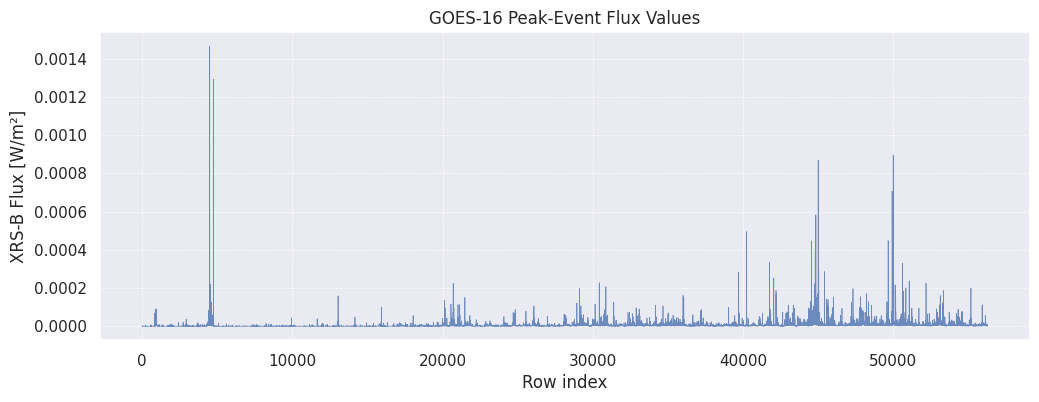

In [13]:
# Quick visualization: peak event fluxes (GOES-16)
fig, ax = plt.subplots(figsize=(12, 4))
nc_df_16[nc_df_16['status'] == "EVENT_PEAK"]["xrsb_flux"].astype(float).plot(
    ax=ax, kind='line', linewidth=0.5, alpha=0.8
)
ax.set_xlabel('Row index')
ax.set_ylabel('XRS-B Flux [W/m²]')
ax.set_title('GOES-16 Peak-Event Flux Values')
ax.grid(ls='--', linewidth=0.5)
plt.show()

In [14]:
# ---------------------------------------------------------------------------
# 3. Transform netCDF rows into flare-event records
# ---------------------------------------------------------------------------
# Each flare has 3–4 rows (EVENT_START, EVENT_PEAK, EVENT_END, optionally
# POST_EVENT). We collapse them into a single row per flare_id.

# Reference coordinates: geometric center of Mexico
LAT = 24.05754867
LON = -104.0226393

# netCDF time is stored as "seconds since 2000-01-01 12:00:00"
BASE_DATE = datetime(2000, 1, 1, 12, 0, 0)


def combine_flares(flares: pd.DataFrame):
    """
    Collapse per-status rows into one row per flare event.

    For each unique flare_id, extract start/peak/end timestamps,
    compute solar altitude/azimuth at peak, and collect the
    integrated flux at event end and the peak XRS-B flux.

    Parameters
    ----------
    flares : pd.DataFrame
        Raw netCDF data with per-status rows (EVENT_START, EVENT_PEAK, etc.)
    """
    flare_ids = flares["flare_id"].unique()
    flare_count = len(flare_ids)

    data = {
        "event_start":          [],
        "event_max":            [],
        "event_finish":         [],
        "magnitude":            [],
        "altitude":             [],
        "azimuth":              [],
        "integrated_flux_end":  [],
        "xrsb_flux_peak":       [],
    }

    i = 0
    for id_ in flare_ids:
        event = flares[flares["flare_id"] == id_]

        # Some flares are missing one or more of the required status rows
        if event.shape[0] < 3:
            continue

        try:
            # --- Flare classification (e.g. "B3.8", "X12.9") ---
            flare_type = ''.join(
                event[event["status"] == "EVENT_PEAK"]["flare_class"].iloc[0]
            )

            # --- Integrated flux at event end (J/m²) ---
            integrated_flux_end = float(
                event[event["status"] == "EVENT_END"]["integrated_flux"].iloc[0]
            )

            # --- Peak XRS-B flux (W/m²) ---
            xrsb_flux_peak = float(
                event[event["status"] == "EVENT_PEAK"]["xrsb_flux"].iloc[0]
            )

            # --- Timestamps (seconds since BASE_DATE) ---
            event_start  = int(event[event["status"] == "EVENT_START"]["time"].iloc[0])
            event_peak   = int(event[event["status"] == "EVENT_PEAK"]["time"].iloc[0])
            event_finish = int(event[event["status"] == "EVENT_END"]["time"].iloc[0])

            peak_datetime = pytz.utc.localize(BASE_DATE + timedelta(seconds=event_peak))
            start_datetime = pytz.utc.localize(BASE_DATE + timedelta(seconds=event_start))
            finish_datetime = pytz.utc.localize(BASE_DATE + timedelta(seconds=event_finish))

            # --- Solar position at peak (from Mexico's center) ---
            altitude = solar.get_altitude(LAT, LON, peak_datetime)
            azimuth = solar.get_azimuth(LAT, LON, peak_datetime)

            data["magnitude"].append(flare_type)
            data["event_start"].append(start_datetime.isoformat())
            data["event_max"].append(peak_datetime.isoformat())
            data["event_finish"].append(finish_datetime.isoformat())
            data["altitude"].append(altitude)
            data["azimuth"].append(azimuth)
            data["integrated_flux_end"].append(integrated_flux_end)
            data["xrsb_flux_peak"].append(xrsb_flux_peak)
            i += 1

        except IndexError:
            continue

    print(f"Flare events detected: {flare_count}")
    print(f"Successfully processed: {i}")
    print(f"Discarded (missing data): {flare_count - i}")
    return data

In [15]:
# ---------------------------------------------------------------------------
# 3.1 Apply the transformation to GOES-16
# ---------------------------------------------------------------------------

d16 = combine_flares(nc_df_16)
goesr16 = pd.DataFrame(data=d16)
goesr16["event_start"] = pd.to_datetime(goesr16["event_start"])
goesr16["event_finish"] = pd.to_datetime(goesr16["event_finish"])
goesr16["event_max"] = pd.to_datetime(goesr16["event_max"])

goesr16.head()

Flare events detected: 16111
Successfully processed: 13969
Discarded (missing data): 2142


,event_start,event_max,event_finish,magnitude,altitude,azimuth,integrated_flux_end,xrsb_flux_peak
0,2017-02-09 00:41:00+00:00,2017-02-09 00:50:00+00:00,2017-02-09 00:56:00+00:00,B3.7,-1.453833,254.569583,0.000245,3.711663e-07
1,2017-02-09 01:30:00+00:00,2017-02-09 01:40:00+00:00,2017-02-09 01:42:00+00:00,B4.3,-12.567852,259.375135,0.000161,4.310535e-07
2,2017-02-09 01:45:00+00:00,2017-02-09 01:51:00+00:00,2017-02-09 01:55:00+00:00,C1.6,-15.038933,260.390306,0.000643,1.694939e-06
3,2017-02-09 02:31:00+00:00,2017-02-09 02:40:00+00:00,2017-02-09 02:48:00+00:00,B3.2,-26.125422,264.870527,0.000306,3.234027e-07
4,2017-02-09 03:03:00+00:00,2017-02-09 03:09:00+00:00,2017-02-09 03:15:00+00:00,B8.6,-32.728232,267.590496,0.000516,8.685444e-07


In [16]:
# ---------------------------------------------------------------------------
# 3.2 Apply the same transformation to GOES-19
# ---------------------------------------------------------------------------

d19 = combine_flares(nc_df_19)
goesr19 = pd.DataFrame(data=d19)
goesr19["event_start"] = pd.to_datetime(goesr19["event_start"])
goesr19["event_finish"] = pd.to_datetime(goesr19["event_finish"])
goesr19["event_max"] = pd.to_datetime(goesr19["event_max"])

goesr19.head()

Flare events detected: 5060
Successfully processed: 4475
Discarded (missing data): 585


,event_start,event_max,event_finish,magnitude,altitude,azimuth,integrated_flux_end,xrsb_flux_peak
0,2024-09-20 14:45:00+00:00,2024-09-20 14:57:00+00:00,2024-09-20 15:03:00+00:00,C4.0,29.255253,103.505768,0.002646,0.000004
1,2024-09-21 07:05:00+00:00,2024-09-21 07:16:00+00:00,2024-09-21 07:34:00+00:00,C2.0,-64.607201,15.902487,0.003337,0.000002
2,2024-09-21 13:35:00+00:00,2024-09-21 13:41:00+00:00,2024-09-21 13:45:00+00:00,C1.6,12.101256,95.038591,0.000944,0.000002
3,2024-09-21 20:37:00+00:00,2024-09-21 20:46:00+00:00,2024-09-21 20:49:00+00:00,C4.4,52.966485,234.319395,0.001991,0.000004
4,2024-09-22 13:18:00+00:00,2024-09-22 13:27:00+00:00,2024-09-22 13:41:00+00:00,C3.7,8.860667,93.958887,0.003829,0.000004


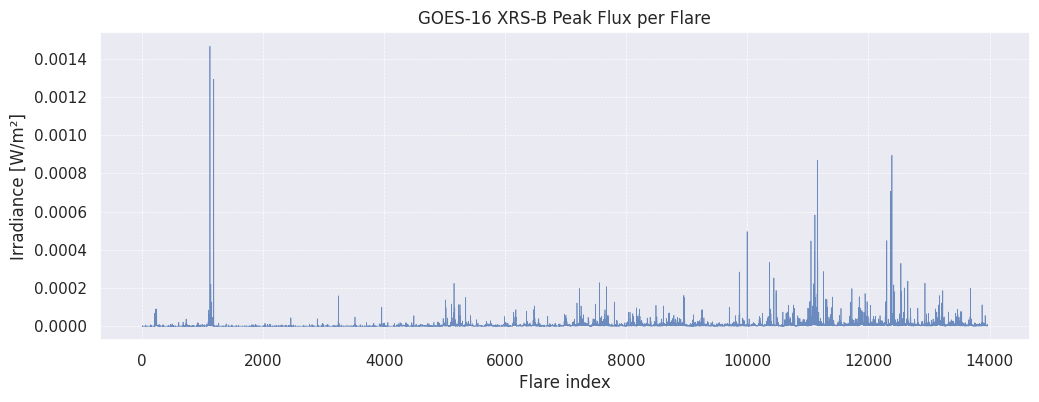

In [17]:
# Quick look: GOES-16 peak flux time series
fig, ax = plt.subplots(figsize=(12, 4))
goesr16["xrsb_flux_peak"].plot(ax=ax, linewidth=0.5, alpha=0.8)
ax.set_xlabel('Flare index')
ax.set_ylabel('Irradiance [W/m²]')
ax.set_title('GOES-16 XRS-B Peak Flux per Flare')
ax.grid(ls='--', linewidth=0.5)
plt.show()

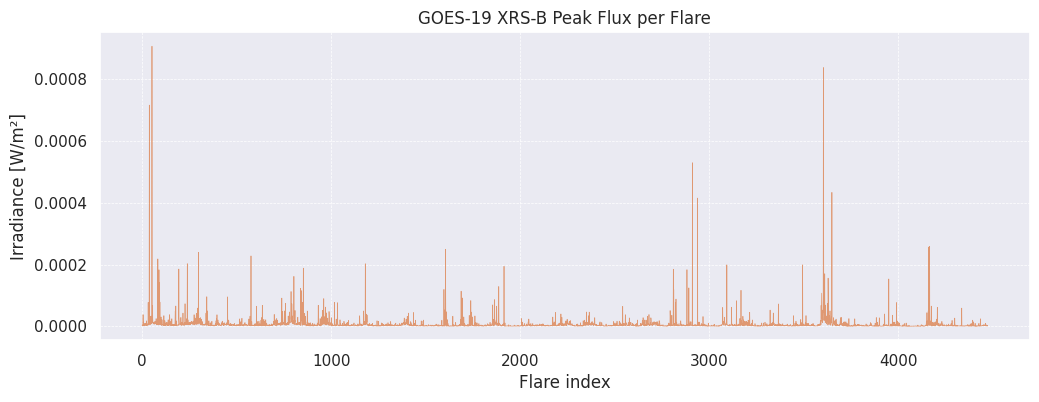

In [18]:
# Quick look: GOES-19 peak flux time series
fig, ax = plt.subplots(figsize=(12, 4))
goesr19["xrsb_flux_peak"].plot(ax=ax, linewidth=0.5, alpha=0.8, color='C1')
ax.set_xlabel('Flare index')
ax.set_ylabel('Irradiance [W/m²]')
ax.set_title('GOES-19 XRS-B Peak Flux per Flare')
ax.grid(ls='--', linewidth=0.5)
plt.show()

In [19]:
# ---------------------------------------------------------------------------
# 4. Flare classification from XRS-B peak flux
# ---------------------------------------------------------------------------
# The traditional GOES flare scale is based on the peak X-ray flux
# in the 0.1–0.8 nm band (XRS-B channel):
#
#   A: < 1e-8  W/m²      C: 1e-6 – 1e-5 W/m²      X: >= 1e-4 W/m²
#   B: 1e-7 – 1e-6       M: 1e-5 – 1e-4


def estimate_flare_category(xrsb_flux_peak: float):
    """Return (letter_class, subcategory_number) for a peak XRS-B flux value."""
    thresholds = [
        ("A", 1e-8, 1e8),
        ("B", 1e-7, 1e7),
        ("C", 1e-6, 1e6),
        ("M", 1e-5, 1e5),
        ("X", 1e-4, 1e4),
    ]
    for letter, limit, multiplier in thresholds:
        if xrsb_flux_peak < limit * 10:
            return letter, round(xrsb_flux_peak * multiplier, 2)
    return "X", round(xrsb_flux_peak * 1e4, 2)


# Quick sanity check
estimate_flare_category(3.800934e-07)

('B', 3.8)

In [20]:
# ---------------------------------------------------------------------------
# 5. Load & correct the SWPC historical flare database
# ---------------------------------------------------------------------------
#
# The SWPC flare catalog (flares-goes-x-ray-unified.dat) contains GOES X-ray
# flare events spanning multiple satellite generations (SMS, GOES-1 through
# GOES-15). The reported fluxes come from different instruments with slightly
# different spectral responses.
#
# --- Scaling factor of 0.7 ---
# The GOES-R series (GOES-16+) uses a redesigned XRS instrument. The XRS-B
# channel (0.1–0.8 nm) on older GOES satellites reports fluxes that are
# systematically ~30 % higher than the equivalent GOES-16 measurement for
# the same solar source. Dividing the legacy SWPC fluxes by 0.7 brings them
# onto the GOES-16 XRS-B scale, enabling a unified catalog.
#
# Ref: See NOAA/NCEI GOES-R EXIS XRS calibration documentation and the
# cross-calibration studies comparing GOES-15 XRS-B to GOES-16 XRS-B.

goes_swpc = pd.read_csv('./data/flares-goes-x-ray-unified.dat', sep='\t')

goes_swpc['t-inicio'] = pd.to_datetime(goes_swpc['t-inicio'])
goes_swpc['t-max'] = pd.to_datetime(goes_swpc['t-max'])
goes_swpc['t-fin'] = pd.to_datetime(goes_swpc['t-fin'])
goes_swpc = goes_swpc.drop(['unknown'], axis=1)

# Keep the uncorrected flux for comparison plots
flux_uncorrected = goes_swpc["total X-ray flux"].copy()

# Apply the 0.7 cross-calibration correction to legacy fluxes
goes_swpc["total X-ray flux"] = goes_swpc["total X-ray flux"] / 0.7

# Standardize column names to match the GOES-R DataFrame
goes_swpc = goes_swpc.rename(columns={
    "Clase":              "classification",
    "Subclase":           "sub_classification",
    "Instrumento":        "observation_instrument",
    "Region":             "AR_id",
    "t-inicio":           "event_start",
    "t-fin":              "event_finish",
    "t-max":              "event_max",
    "total X-ray flux":   "xrsb_flux_peak",
    "altitud":            "altitude",
})

# Filter to GOES-era data only (post-1974)
goes_swpc = goes_swpc[
    goes_swpc['event_max'] >= datetime(1974, 1, 1, 12, 0, 0).isoformat()
]
flux_uncorrected = flux_uncorrected[goes_swpc.index]

goes_swpc.head()

,event_start,event_max,event_finish,classification,sub_classification,observation_instrument,xrsb_flux_peak,AR_id,altitude,azimuth
0,1975-11-05 18:35:00+00:00,1975-11-05 18:59:00+00:00,1975-11-05 19:22:00+00:00,C,5.0,GOES,0.000010,664,53.56,-13.92
1,1975-11-06 01:17:00+00:00,1975-11-06 01:19:00+00:00,1975-11-06 01:26:00+00:00,C,6.0,GOES,0.000012,664,-17.74,-79.18
2,1975-11-06 06:28:00+00:00,1975-11-06 06:29:00+00:00,1975-11-06 06:40:00+00:00,C,3.0,GOES,0.000006,664,-85.88,-194.00
3,1975-11-06 09:22:00+00:00,1975-11-06 09:24:00+00:00,1975-11-06 09:32:00+00:00,C,4.0,GOES,0.000008,664,-47.32,-272.15
4,1975-11-06 11:57:00+00:00,1975-11-06 12:07:00+00:00,1975-11-06 12:18:00+00:00,C,2.0,GOES,0.000004,664,-9.47,-283.60


### Overlap detection — SWPC / GOES-16 / GOES-19

Both SWPC and GOES-16 cover early 2017, and GOES-16 & GOES-19
overlap from 2024-09-20 to 2025-04-06. We trim boundaries to avoid
duplicate flare_ids in the merged catalog.

First, let's verify the overlap between SWPC and GOES-16 by looking at
2017 flares that appear in both datasets.

In [21]:
# GOES-16 flares during 2017 (should overlap with end of SWPC catalog)
goesr16[
    (goesr16['event_start'] > datetime(2017, 1, 1).isoformat()) &
    (goesr16['event_start'] < datetime(2017, 12, 30).isoformat())
]

,event_start,event_max,event_finish,magnitude,altitude,azimuth,integrated_flux_end,xrsb_flux_peak
0,2017-02-09 00:41:00+00:00,2017-02-09 00:50:00+00:00,2017-02-09 00:56:00+00:00,B3.7,-1.453833,254.569583,0.000245,3.711663e-07
1,2017-02-09 01:30:00+00:00,2017-02-09 01:40:00+00:00,2017-02-09 01:42:00+00:00,B4.3,-12.567852,259.375135,0.000161,4.310535e-07
2,2017-02-09 01:45:00+00:00,2017-02-09 01:51:00+00:00,2017-02-09 01:55:00+00:00,C1.6,-15.038933,260.390306,0.000643,1.694939e-06
3,2017-02-09 02:31:00+00:00,2017-02-09 02:40:00+00:00,2017-02-09 02:48:00+00:00,B3.2,-26.125422,264.870527,0.000306,3.234027e-07
4,2017-02-09 03:03:00+00:00,2017-02-09 03:09:00+00:00,2017-02-09 03:15:00+00:00,B8.6,-32.728232,267.590496,0.000516,8.685444e-07
...,...,...,...,...,...,...,...,...
1323,2017-12-23 06:20:00+00:00,2017-12-23 06:29:00+00:00,2017-12-23 06:31:00+00:00,B4.5,-83.991238,274.715216,0.000097,4.561363e-07
1324,2017-12-23 08:57:00+00:00,2017-12-23 09:05:00+00:00,2017-12-23 09:13:00+00:00,B1.3,-60.349752,95.495209,0.000113,1.302622e-07
1325,2017-12-23 20:30:00+00:00,2017-12-23 20:36:00+00:00,2017-12-23 20:43:00+00:00,B1.1,36.640492,209.069227,0.000071,1.133162e-07
1326,2017-12-28 22:25:00+00:00,2017-12-28 22:29:00+00:00,2017-12-28 22:32:00+00:00,C1.2,20.338057,231.272459,0.000307,1.278483e-06


In [22]:
# GOES-16 flares from Feb 8–10 2017 (first days of GOES-16 coverage)
goesr16[
    (goesr16['event_start'] > datetime(2017, 2, 8).isoformat()) &
    (goesr16['event_start'] < datetime(2017, 2, 10).isoformat())
]

,event_start,event_max,event_finish,magnitude,altitude,azimuth,integrated_flux_end,xrsb_flux_peak
0,2017-02-09 00:41:00+00:00,2017-02-09 00:50:00+00:00,2017-02-09 00:56:00+00:00,B3.7,-1.453833,254.569583,0.000245,3.711663e-07
1,2017-02-09 01:30:00+00:00,2017-02-09 01:40:00+00:00,2017-02-09 01:42:00+00:00,B4.3,-12.567852,259.375135,0.000161,4.310535e-07
2,2017-02-09 01:45:00+00:00,2017-02-09 01:51:00+00:00,2017-02-09 01:55:00+00:00,C1.6,-15.038933,260.390306,0.000643,1.694939e-06
3,2017-02-09 02:31:00+00:00,2017-02-09 02:40:00+00:00,2017-02-09 02:48:00+00:00,B3.2,-26.125422,264.870527,0.000306,3.234027e-07
4,2017-02-09 03:03:00+00:00,2017-02-09 03:09:00+00:00,2017-02-09 03:15:00+00:00,B8.6,-32.728232,267.590496,0.000516,8.685444e-07
5,2017-02-09 03:21:00+00:00,2017-02-09 03:26:00+00:00,2017-02-09 03:28:00+00:00,C2.0,-36.606032,269.254073,0.000690,2.043853e-06
6,2017-02-09 05:28:00+00:00,2017-02-09 05:42:00+00:00,2017-02-09 05:49:00+00:00,B8.8,-67.180557,290.432406,0.000697,8.824123e-07
7,2017-02-09 06:03:00+00:00,2017-02-09 06:12:00+00:00,2017-02-09 06:15:00+00:00,B5.2,-73.339421,301.949954,0.000279,5.243432e-07
8,2017-02-09 06:28:00+00:00,2017-02-09 06:35:00+00:00,2017-02-09 06:39:00+00:00,B4.4,-77.410421,317.157772,0.000250,4.446707e-07
9,2017-02-09 06:51:00+00:00,2017-02-09 07:02:00+00:00,2017-02-09 07:04:00+00:00,C1.7,-80.330541,348.046649,0.000605,1.796488e-06


In [23]:
# Examine SWPC flares from February 2017 (last month before GOES-16 data takes over)
goes_swpc[
    (goes_swpc['event_start'] > datetime(2017, 2, 1).isoformat()) &
    (goes_swpc['event_start'] < datetime(2017, 2, 28).isoformat())
]

,event_start,event_max,event_finish,classification,sub_classification,observation_instrument,xrsb_flux_peak,AR_id,altitude,azimuth
76417,2017-02-04 05:57:00+00:00,2017-02-04 06:00:00+00:00,2017-02-04 06:04:00+00:00,B,1.1,G15,2.244900e-07,0,-76.41,-103.38
76418,2017-02-04 12:59:00+00:00,2017-02-04 13:12:00+00:00,2017-02-04 13:45:00+00:00,B,1.6,G15,3.265300e-07,0,-0.87,-286.52
76419,2017-02-06 16:16:00+00:00,2017-02-06 16:22:00+00:00,2017-02-06 16:31:00+00:00,B,1.5,G15,3.061229e-07,0,38.45,-310.27
76420,2017-02-08 23:08:00+00:00,2017-02-08 23:11:00+00:00,2017-02-08 23:18:00+00:00,B,1.1,G15,2.244900e-07,0,18.37,-66.22
76421,2017-02-09 00:42:00+00:00,2017-02-09 00:50:00+00:00,2017-02-09 00:55:00+00:00,B,2.6,G15,5.306129e-07,0,-3.44,-75.73
76422,2017-02-09 01:35:00+00:00,2017-02-09 01:40:00+00:00,2017-02-09 01:42:00+00:00,B,3.1,G15,6.326529e-07,0,-15.24,-79.58
76423,2017-02-09 01:45:00+00:00,2017-02-09 01:51:00+00:00,2017-02-09 01:56:00+00:00,C,1.1,G15,2.244900e-06,0,-17.78,-80.38
76424,2017-02-09 02:56:00+00:00,2017-02-09 03:09:00+00:00,2017-02-09 03:16:00+00:00,B,6.0,G15,1.224490e-06,0,-35.95,-85.95
76425,2017-02-09 03:20:00+00:00,2017-02-09 03:26:00+00:00,2017-02-09 03:29:00+00:00,C,1.3,G15,2.653057e-06,0,-39.94,-87.21
76426,2017-02-09 05:31:00+00:00,2017-02-09 05:42:00+00:00,2017-02-09 05:49:00+00:00,B,6.0,G15,1.224490e-06,0,-71.74,-103.67


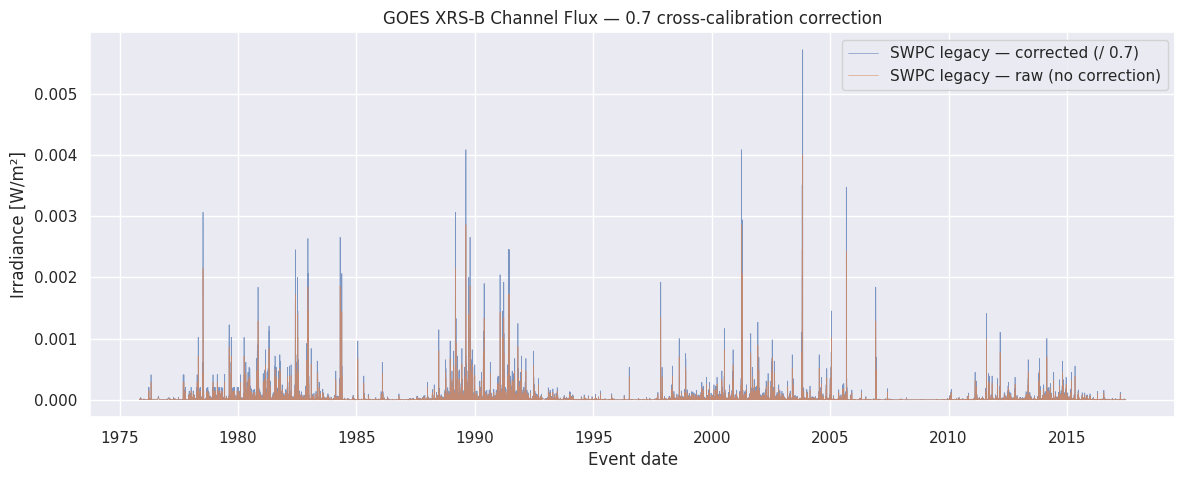

In [24]:
# ---------------------------------------------------------------------------
# 5.1 Visual comparison: corrected vs. uncorrected legacy fluxes
# ---------------------------------------------------------------------------
# The 0.7 correction shifts fluxes upward to match the GOES-16/GOES-19 XRS-B scale.

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(goes_swpc['event_max'], goes_swpc['xrsb_flux_peak'],
        label="SWPC legacy — corrected (/ 0.7)", alpha=0.7, linewidth=0.5)
ax.plot(goes_swpc['event_max'], flux_uncorrected,
        label="SWPC legacy — raw (no correction)", alpha=0.7, linewidth=0.5)

ax.set_xlabel('Event date')
ax.set_ylabel('Irradiance [W/m²]')
ax.set_title('GOES XRS-B Channel Flux — 0.7 cross-calibration correction')
ax.legend()
plt.show()

In [25]:
# Trim SWPC data to pre-GOES-16 era only (index 76420 ≈ Feb 2017)
goes_swpc = goes_swpc[goes_swpc.index < 76421]
goes_swpc.tail()

,event_start,event_max,event_finish,classification,sub_classification,observation_instrument,xrsb_flux_peak,AR_id,altitude,azimuth
76416,2017-01-28 20:56:00+00:00,2017-01-28 21:09:00+00:00,2017-01-28 21:21:00+00:00,C,2.8,G15,5.714286e-06,0,39.82,-43.38
76417,2017-02-04 05:57:00+00:00,2017-02-04 06:00:00+00:00,2017-02-04 06:04:00+00:00,B,1.1,G15,2.244900e-07,0,-76.41,-103.38
76418,2017-02-04 12:59:00+00:00,2017-02-04 13:12:00+00:00,2017-02-04 13:45:00+00:00,B,1.6,G15,3.265300e-07,0,-0.87,-286.52
76419,2017-02-06 16:16:00+00:00,2017-02-06 16:22:00+00:00,2017-02-06 16:31:00+00:00,B,1.5,G15,3.061229e-07,0,38.45,-310.27
76420,2017-02-08 23:08:00+00:00,2017-02-08 23:11:00+00:00,2017-02-08 23:18:00+00:00,B,1.1,G15,2.244900e-07,0,18.37,-66.22


In [26]:
# ---------------------------------------------------------------------------
# 5.2 Recompute flare magnitudes from corrected fluxes
# ---------------------------------------------------------------------------
# The "classification" and "sub_classification" columns in the SWPC catalog
# were derived from the *uncorrected* fluxes. After the /0.7 correction,
# we recompute the magnitude string (e.g. "C5.7") from the corrected flux.

magnitudes = []
for flux_val in goes_swpc['xrsb_flux_peak']:
    cat, sub = estimate_flare_category(flux_val)
    magnitudes.append(f"{cat}{sub}")

goes_swpc['magnitude'] = magnitudes
goes_swpc = goes_swpc.drop(
    columns=['classification', 'sub_classification',
             'observation_instrument', 'AR_id']
)

# GOES-19 data starts 2024-09-20. Trim GOES-16 at this date to avoid overlap,
# then drop the integrated_flux_end column from both to align schemas.
GOES_19_START = datetime(2024, 9, 20, tzinfo=pytz.utc)

goesr16_trimmed = goesr16[goesr16['event_start'] < GOES_19_START]
print(f"GOES-16 flares before {GOES_19_START.date()}: {len(goesr16_trimmed)}")
print(f"GOES-16 flares removed (overlap with GOES-19): {len(goesr16) - len(goesr16_trimmed)}")

goesr16_clean = goesr16_trimmed.drop(columns=['integrated_flux_end'])
goesr19_clean = goesr19.drop(columns=['integrated_flux_end'])

GOES-16 flares before 2024-09-20: 12322
GOES-16 flares removed (overlap with GOES-19): 1647


In [27]:
# ---------------------------------------------------------------------------
# 6. Merge: SWPC (1975–2017) + GOES-16 (2017–2024) + GOES-19 (2024–present)
# ---------------------------------------------------------------------------

all_df = pd.concat([goes_swpc, goesr16_clean, goesr19_clean], ignore_index=True)
print(f"Total unified catalog: {len(all_df)} flares")
print(f"Date range: {all_df['event_start'].min()} to {all_df['event_start'].max()}")
all_df

Total unified catalog: 93025 flares
Date range: 1975-11-05 18:35:00+00:00 to 2026-05-28 16:28:00+00:00


,event_start,event_max,event_finish,xrsb_flux_peak,altitude,azimuth,magnitude
0,1975-11-05 18:35:00+00:00,1975-11-05 18:59:00+00:00,1975-11-05 19:22:00+00:00,0.000010,53.560000,-13.920000,M1.02
1,1975-11-06 01:17:00+00:00,1975-11-06 01:19:00+00:00,1975-11-06 01:26:00+00:00,0.000012,-17.740000,-79.180000,M1.22
2,1975-11-06 06:28:00+00:00,1975-11-06 06:29:00+00:00,1975-11-06 06:40:00+00:00,0.000006,-85.880000,-194.000000,C6.12
3,1975-11-06 09:22:00+00:00,1975-11-06 09:24:00+00:00,1975-11-06 09:32:00+00:00,0.000008,-47.320000,-272.150000,C8.16
4,1975-11-06 11:57:00+00:00,1975-11-06 12:07:00+00:00,1975-11-06 12:18:00+00:00,0.000004,-9.470000,-283.600000,C4.08
...,...,...,...,...,...,...,...
93020,2026-05-27 13:19:00+00:00,2026-05-27 13:23:00+00:00,2026-05-27 13:29:00+00:00,0.000003,15.044333,72.943024,C2.8
93021,2026-05-28 07:52:00+00:00,2026-05-28 08:00:00+00:00,2026-05-28 08:07:00+00:00,0.000001,-41.662623,20.931408,C1.1
93022,2026-05-28 09:58:00+00:00,2026-05-28 10:09:00+00:00,2026-05-28 10:20:00+00:00,0.000002,-24.142645,50.221141,C1.8
93023,2026-05-28 15:09:00+00:00,2026-05-28 15:16:00+00:00,2026-05-28 15:18:00+00:00,0.000003,40.166530,81.420117,C3.2


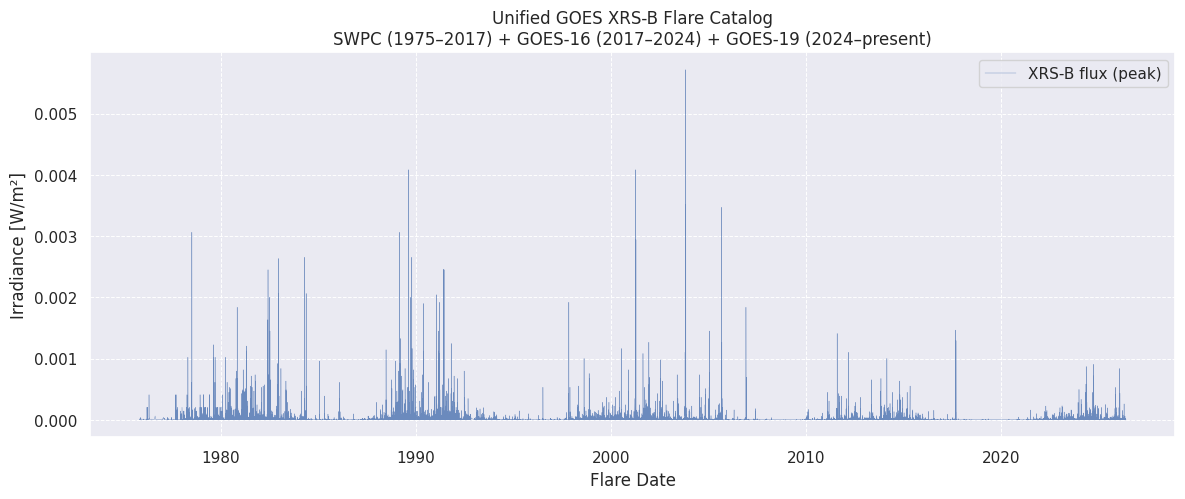

In [28]:
# ---------------------------------------------------------------------------
# 7. Visualize the unified catalog
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(all_df['event_max'], all_df['xrsb_flux_peak'],
        linewidth=0.3, alpha=0.8, label="XRS-B flux (peak)")
ax.set_xlabel('Flare Date')
ax.set_ylabel('Irradiance [W/m²]')
ax.set_title('Unified GOES XRS-B Flare Catalog\nSWPC (1975–2017) + GOES-16 (2017–2024) + GOES-19 (2024–present)')
ax.grid(ls='--', linewidth=0.7)
ax.legend()
plt.show()

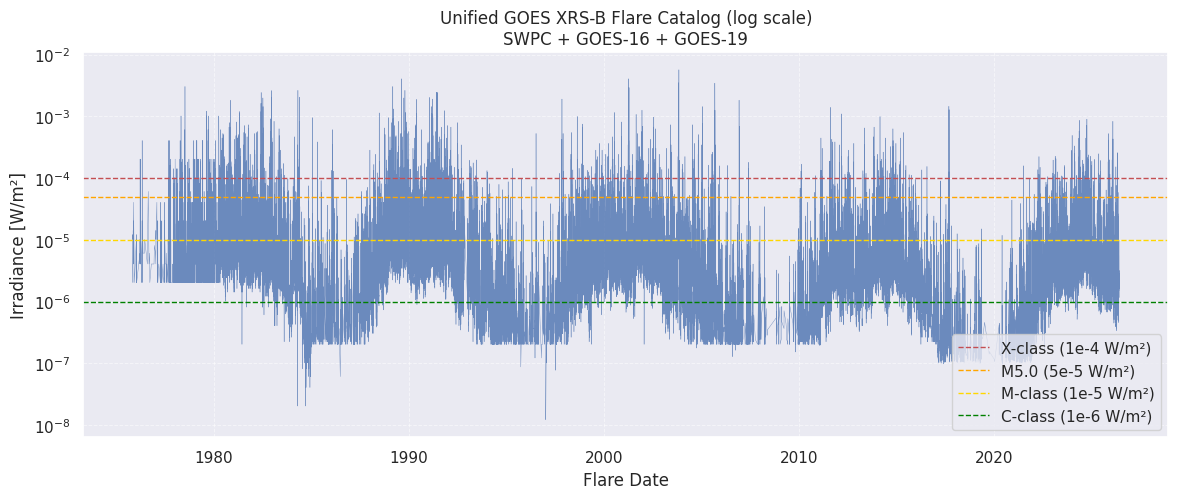

In [29]:
# Log-scale view with flare-class reference lines
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(all_df['event_max'], all_df['xrsb_flux_peak'],
        linewidth=0.3, alpha=0.8)
ax.axhline(y=1e-4, color='r', linestyle='--', label='X-class (1e-4 W/m²)', linewidth=1)
ax.axhline(y=5e-5, color='orange', linestyle='--', label='M5.0 (5e-5 W/m²)', linewidth=1)
ax.axhline(y=1e-5, color='gold', linestyle='--', label='M-class (1e-5 W/m²)', linewidth=1)
ax.axhline(y=1e-6, color='green', linestyle='--', label='C-class (1e-6 W/m²)', linewidth=1)

ax.set_xlabel('Flare Date')
ax.set_ylabel('Irradiance [W/m²]')
ax.set_yscale('log')
ax.set_title('Unified GOES XRS-B Flare Catalog (log scale)\nSWPC + GOES-16 + GOES-19')
ax.grid(ls='--', linewidth=0.7, alpha=0.5)
ax.legend(loc='lower right')
plt.show()

## TODO

1. ~~Fix magnitudes after flux rescaling~~
2. ~~Include GOES-19 data~~
3. **Automation:**
   - Create a standalone Python script from this notebook
   - Integrate with the GOES-19 data download (Vidal's script)
   - Build a unified SQL database with the merged catalog
   - Deploy a REST API for data querying
   - Containerize the full pipeline (Docker)

In [30]:
# Export the unified catalog to CSV
# all_df.to_csv('data/flare_summary_goes_xrsb_flux_complete.csv', index=False)
# all_df.to_excel('data/flare_summary_goes_xrsb_flux_complete.xlsx', index=False)